# M2 CrossFit：新增高分辨率标签训练、外部评估与候选导出

本 Notebook 从项目缓存开始执行完整流程，输出两个核心结果：

1. 用原 91 颗证认 CN 星训练原始 crossfit，在 99 个新增高分辨率标签上复现加入前的外部评估；
2. 将 46 个新增正例和 53 个可靠负例纳入 M2，使用严格 OOF 分数定义 90% 正例召回阈值，并导出候选表与 91 星识别表。

## 指标解释

- **0.911 ± 0.031 / 0.876**：原 91 星 crossfit 对 99 个新增标签的外部 ROC-AUC（± Hanley-McNeil 标准误）和 PR-AUC。
- **M2 新标签 OOF 指标**：99 个新标签做 5 折；被评分对象不出现在训练正例、可靠负例或 U 采样池中。
- **90% 阈值**：137 个确认正例的 OOF 分数中第 `ceil(137×0.90)=124` 高分。它是固定召回阈值，不是 90% 后验概率。
- **候选入选和 91 星 label**：只使用 OOF 分数。全标签 ensemble 分数仅作为补充排序列。

## 0. 环境、路径与配置

In [1]:
from pathlib import Path
import json
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_curve, precision_recall_curve,
)

def find_project_root(start):
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "build_dr13_all_cache.py").exists():
            return candidate
    raise FileNotFoundError("cannot locate project root")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from build_dr13_all_cache import load_dr13_all_cache
from crossfit import crossfit_engine as baseline_engine
from m2_crossfit.m2_crossfit_engine import (
    M2Config, build_status, build_output_tables, evaluate_scores,
    map_new_labels, prepare_features, run_m2_crossfit,
    run_newlabel_oof_m2, save_outputs, train_full_ensemble,
)

HERE = PROJECT_ROOT / "m2_crossfit"
RESULTS_DIR = HERE / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SMOKE = os.environ.get("M2_SMOKE", "0") == "1"
if SMOKE:
    baseline_config = baseline_engine.CrossFitConfig(
        u_to_p_ratio=2, n_splits=3, n_repeats=1, n_bags=2,
        num_boost_round=3, target_recall=0.90, random_seed=42,
    )
    m2_config = M2Config(
        u_to_p_ratio=2, n_splits=3, n_repeats=1, n_bags=2,
        num_boost_round=3, target_recall=0.90, random_seed=42,
    )
    newlabel_config = M2Config(
        u_to_p_ratio=2, n_splits=3, n_repeats=1, n_bags=2,
        num_boost_round=3, target_recall=0.90, random_seed=42,
    )
else:
    baseline_config = baseline_engine.CrossFitConfig(
        u_to_p_ratio=10, max_depth=3, min_child_weight=1, reg_lambda=1.0,
        n_splits=5, n_repeats=3, n_bags=100, num_boost_round=50,
        target_recall=0.90, random_seed=42, standardize=True,
    )
    m2_config = M2Config(
        u_to_p_ratio=10, max_depth=3, min_child_weight=1, reg_lambda=1.0,
        n_splits=5, n_repeats=3, n_bags=100, num_boost_round=50,
        target_recall=0.90, random_seed=42, standardize=True,
    )
    # 与已有 add-sample 正式实验保持 80 bags，但修正 held-out 标签泄漏。
    newlabel_config = M2Config(
        u_to_p_ratio=10, max_depth=3, min_child_weight=1, reg_lambda=1.0,
        n_splits=5, n_repeats=1, n_bags=80, num_boost_round=50,
        target_recall=0.90, random_seed=42, standardize=True,
    )

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
})
print("Python       :", sys.executable)
print("Project root :", PROJECT_ROOT)
print("Output       :", RESULTS_DIR)
print("Smoke mode   :", SMOKE)
print("Baseline cfg :", baseline_config)
print("M2 cfg       :", m2_config)

Python       : D:\Anaconda\envs\myenv\python.exe
Project root : D:\资料\2026大创\Lamost
Output       : D:\资料\2026大创\Lamost\m2_crossfit\results
Smoke mode   : False
Baseline cfg : CrossFitConfig(u_to_p_ratio=10, max_depth=3, min_child_weight=1, reg_lambda=1.0, n_splits=5, n_repeats=3, n_bags=100, num_boost_round=50, target_recall=0.9, random_seed=42, standardize=True)
M2 cfg       : M2Config(u_to_p_ratio=10, max_depth=3, min_child_weight=1, reg_lambda=1.0, n_splits=5, n_repeats=3, n_bags=100, num_boost_round=50, target_recall=0.9, random_seed=42, standardize=True)


## 1. 加载数据并冻结标签身份

这里进行 UID 级校验。新增标签必须满足：99 个 UID 唯一、全部能映射到 41,243 条母样本、标签只含 0/1、与原 91 颗正例零重叠。

In [2]:
data = load_dr13_all_cache()
stars = pd.DataFrame(data["stars_clean"]).reset_index(drop=True)
X_model = prepare_features(data["X_clean"], standardize=True)
wave = np.asarray(data["common_wave"])

highres = pd.read_csv(PROJECT_ROOT / "diagnosis" / "cands_label.csv")
mapping = map_new_labels(stars, highres)
old_positive = np.asarray(mapping["old_positive"], dtype=int)
new_positive = np.asarray(mapping["new_positive"], dtype=int)
new_negative = np.asarray(mapping["new_negative"], dtype=int)
status = build_status(len(stars), old_positive, new_positive, new_negative)

print(f"母样本: {len(stars):,}")
print(f"旧正例: {old_positive.size}")
print(f"新增正例: {new_positive.size}")
print(f"可靠负例: {new_negative.size}")
print(f"普通 U: {(status == 0).sum():,}")
assert len(stars) == 41243
assert old_positive.size == 91
assert new_positive.size == 46
assert new_negative.size == 53
assert np.unique(np.concatenate([old_positive, new_positive, new_negative])).size == 190

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91


母样本: 41,243
旧正例: 91
新增正例: 46
可靠负例: 53
普通 U: 41,053


## 2. 原始 91 星 crossfit：复现 99 标签外部指标

这一段重新训练原始 crossfit。99 个高分辨率标签不作为正例或可靠负例；它们只在各自 OOF 分数生成后用于外部评估。

In [3]:
baseline_started = time.perf_counter()
baseline_y = baseline_engine.label_array(stars)
baseline_result = baseline_engine.run_crossfit_pu(
    X_model, baseline_y, baseline_config, progress=True
)
new_label_table = mapping["labels"].copy()
new_rows = new_label_table["source_index"].to_numpy(dtype=int)
new_y = new_label_table["label"].to_numpy(dtype=int)
baseline_new_scores = np.asarray(baseline_result["score_mean"])[new_rows]
baseline_audit = evaluate_scores(new_y, baseline_new_scores)
pd.DataFrame(baseline_result["history"]).to_csv(
    RESULTS_DIR / "baseline_training_history.csv", index=False
)
print(json.dumps(baseline_audit, indent=2, ensure_ascii=False))
print(f"baseline elapsed: {time.perf_counter() - baseline_started:.1f}s")
if not SMOKE:
    assert abs(baseline_audit["roc_auc"] - 0.9109926168990976) < 1e-10
    assert abs(baseline_audit["pr_auc"] - 0.8763481932761269) < 1e-10

Repeat 1/3 (U:P=10:1)


  fold 1/5: P_train=73, U/bag=730, ROC=0.9766, PR=0.3321, 139.0s


  fold 2/5: P_train=73, U/bag=730, ROC=0.9130, PR=0.6000, 135.7s


  fold 3/5: P_train=72, U/bag=720, ROC=0.9962, PR=0.4871, 138.9s


  fold 4/5: P_train=73, U/bag=730, ROC=0.9950, PR=0.3566, 76.0s


...

  fold 2/5: P_train=73, U/bag=730, ROC=0.9431, PR=0.2565, 69.2s


  fold 3/5: P_train=72, U/bag=720, ROC=0.9951, PR=0.3588, 64.0s


  fold 4/5: P_train=73, U/bag=730, ROC=0.9313, PR=0.5055, 64.0s


  fold 5/5: P_train=73, U/bag=730, ROC=0.9984, PR=0.6428, 64.7s


{
  "roc_auc": 0.9109926168990976,
  "roc_auc_se": 0.03130555326667781,
  "pr_auc": 0.8763481932761269,
  "positive_score_median": 0.5147893987596035,
  "negative_score_median": 0.053986020047838486
}
baseline elapsed: 1247.3s


### 2.1 基线 ROC、PR 与分数分布

ROC-AUC 描述排序能力；PR-AUC 更关注稀有正类。标准误只附在 ROC-AUC 上，PR-AUC 不使用相同的解析标准误公式。

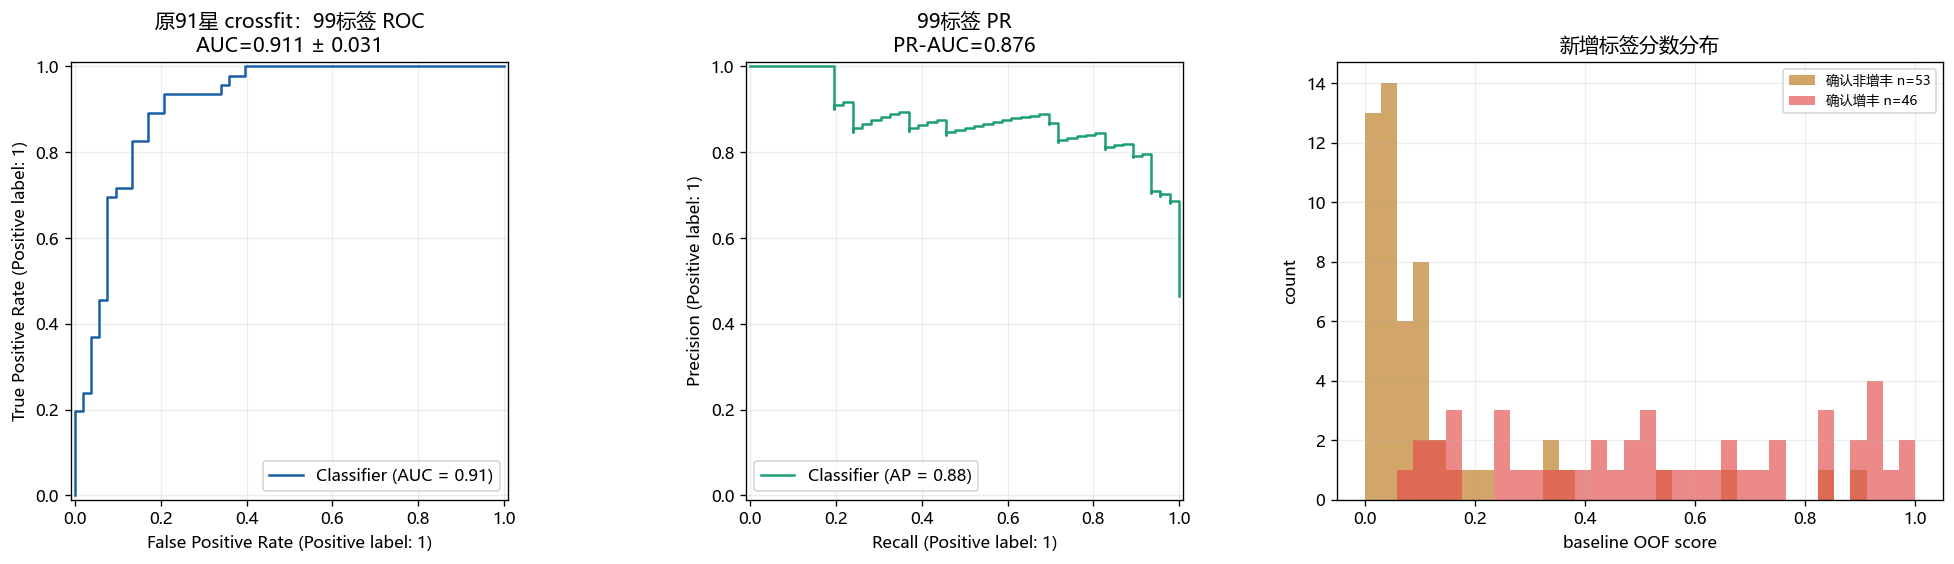

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
RocCurveDisplay.from_predictions(new_y, baseline_new_scores, ax=axes[0], color="#185FA5")
axes[0].set_title(
    f"原91星 crossfit：99标签 ROC\n"
    f"AUC={baseline_audit['roc_auc']:.3f} ± {baseline_audit['roc_auc_se']:.3f}"
)
PrecisionRecallDisplay.from_predictions(
    new_y, baseline_new_scores, ax=axes[1], color="#1D9E75"
)
axes[1].set_title(f"99标签 PR\nPR-AUC={baseline_audit['pr_auc']:.3f}")
bins = np.linspace(0, 1, 35)
axes[2].hist(baseline_new_scores[new_y == 0], bins=bins, alpha=.65,
             label="确认非增丰 n=53", color="#BA7517")
axes[2].hist(baseline_new_scores[new_y == 1], bins=bins, alpha=.65,
             label="确认增丰 n=46", color="#E24B4A")
axes[2].set_xlabel("baseline OOF score")
axes[2].set_ylabel("count")
axes[2].set_title("新增标签分数分布")
axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_baseline_external_audit.png", dpi=170, bbox_inches="tight")
plt.show()

## 3. 严格 M2：99 个新增标签 5 折 OOF

旧实验把 held-out 新标签保留在普通 U 池中，因此它们可能被抽成伪负样本。本流程把所有 99 个新标签从普通 U 池移除；每折只允许其余 4 折的新标签进入正例或可靠负例训练集合。

In [5]:
newlabel_oof = run_newlabel_oof_m2(
    X_model,
    old_positive,
    new_positive,
    new_negative,
    newlabel_config,
    progress=True,
)
newlabel_audit = evaluate_scores(
    np.asarray(newlabel_oof["labels"]), np.asarray(newlabel_oof["oof_score"])
)
newlabel_oof["fold_metrics"].to_csv(
    RESULTS_DIR / "m2_newlabel_fold_metrics.csv", index=False
)
print(json.dumps(newlabel_audit, indent=2, ensure_ascii=False))
display(newlabel_oof["fold_metrics"])

new-label fold 1/5: ROC=0.9000, PR=0.8656, 65.1s


new-label fold 2/5: ROC=1.0000, PR=1.0000, 65.1s


new-label fold 3/5: ROC=0.8990, PR=0.8517, 65.0s


new-label fold 4/5: ROC=0.9495, PR=0.9460, 65.1s


new-label fold 5/5: ROC=0.9444, PR=0.9283, 64.2s


{
  "roc_auc": 0.9392945036915504,
  "roc_auc_se": 0.025936062787804186,
  "pr_auc": 0.908710083494441,
  "positive_score_median": 0.7208262997679413,
  "negative_score_median": 0.042667934042401615
}


,fold,n_train_positive,n_train_reliable_negative,n_holdout,roc_auc,pr_auc,seconds
0,1,127,43,20,0.900000,0.865588,65.131283
1,2,128,42,20,1.000000,1.000000,65.106600
2,3,128,42,20,0.898990,0.851720,65.007621
3,4,128,42,20,0.949495,0.945988,65.110331
4,5,128,43,19,0.944444,0.928263,64.167377


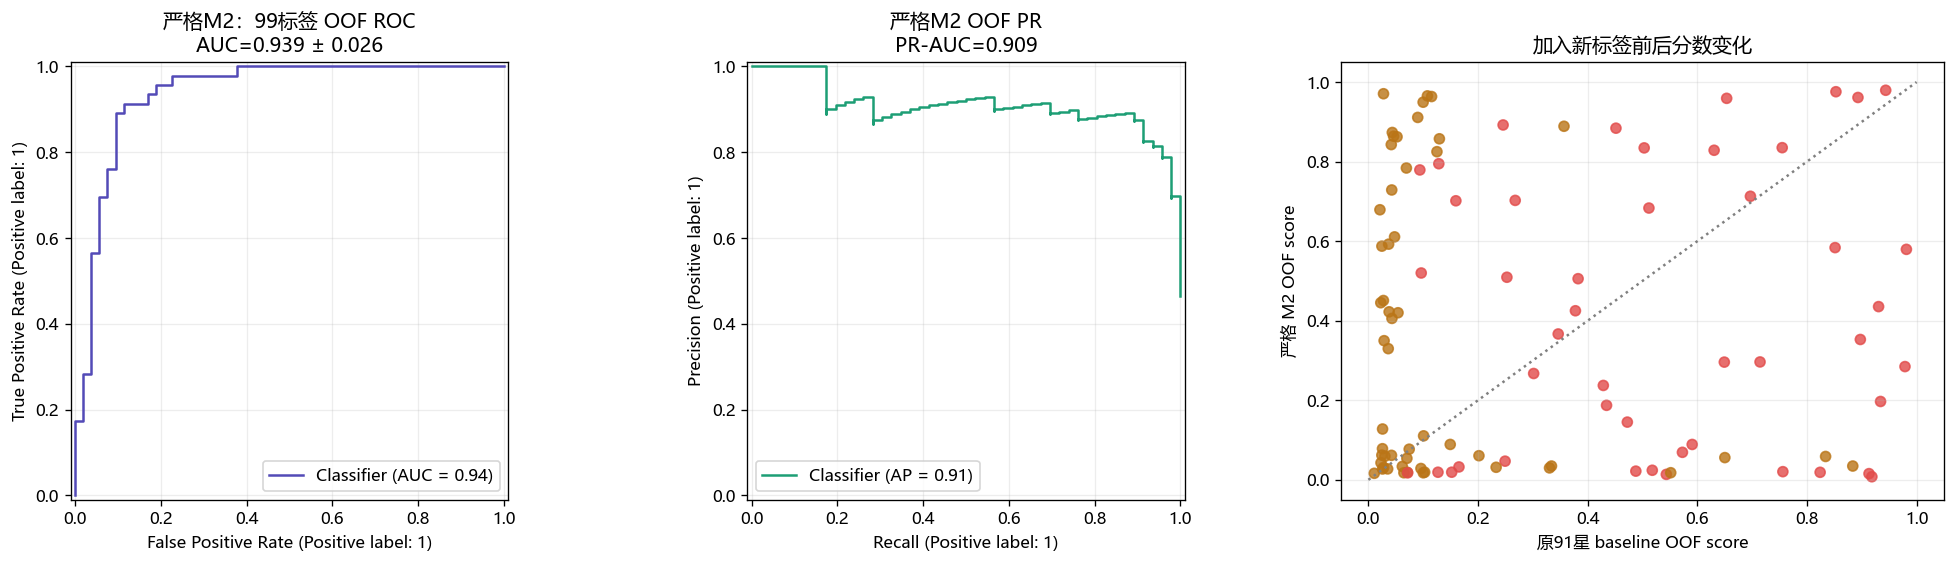

In [6]:
m2_new_y = np.asarray(newlabel_oof["labels"])
m2_new_score = np.asarray(newlabel_oof["oof_score"])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
RocCurveDisplay.from_predictions(m2_new_y, m2_new_score, ax=axes[0], color="#534AB7")
axes[0].set_title(
    f"严格M2：99标签 OOF ROC\n"
    f"AUC={newlabel_audit['roc_auc']:.3f} ± {newlabel_audit['roc_auc_se']:.3f}"
)
PrecisionRecallDisplay.from_predictions(
    m2_new_y, m2_new_score, ax=axes[1], color="#1D9E75"
)
axes[1].set_title(f"严格M2 OOF PR\nPR-AUC={newlabel_audit['pr_auc']:.3f}")
axes[2].scatter(baseline_new_scores, m2_new_score,
                c=np.where(new_y == 1, "#E24B4A", "#BA7517"), alpha=.8)
axes[2].plot([0, 1], [0, 1], color="gray", ls=":")
axes[2].set_xlabel("原91星 baseline OOF score")
axes[2].set_ylabel("严格 M2 OOF score")
axes[2].set_title("加入新标签前后分数变化")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_strict_m2_newlabel_oof.png", dpi=170, bbox_inches="tight")
plt.show()

## 4. 全样本 M2 CrossFit

137 个确认正例、53 个可靠负例和 41,053 个普通 U 一起进入三类分层 crossfit。可靠负例在训练折中被强制加入每个 bag；holdout 中的任何对象都不会进入该模型训练。

In [7]:
m2_result = run_m2_crossfit(X_model, status, m2_config, progress=True)
print("labelled OOF ROC-AUC:", m2_result["labelled_roc_auc"])
print("labelled OOF PR-AUC :", m2_result["labelled_pr_auc"])
print("recall90 threshold  :", m2_result["threshold"])
print("required positives  :", m2_result["required_positive"])
print("achieved recall     :", m2_result["achieved_positive_recall"])
print("repeat thresholds   :", np.asarray(m2_result["repeat_thresholds"]).round(6))
print("repeat candidates   :", np.asarray(m2_result["repeat_candidate_counts"]))
assert int(m2_result["required_positive"]) == 124
assert float(m2_result["achieved_positive_recall"]) >= 0.90

M2 repeat 1/3


  fold 1/5: P=110, RN=42, ROC=0.8788, PR=0.9585, 76.4s


  fold 2/5: P=110, RN=42, ROC=0.9562, PR=0.9794, 125.3s


  fold 3/5: P=110, RN=42, ROC=0.9158, PR=0.9664, 177.9s


  fold 4/5: P=109, RN=43, ROC=0.8929, PR=0.9584, 180.9s


...

  fold 2/5: P=110, RN=42, ROC=0.9764, PR=0.9914, 164.2s


  fold 3/5: P=110, RN=42, ROC=1.0000, PR=1.0000, 164.6s


  fold 4/5: P=109, RN=43, ROC=0.8286, PR=0.9328, 160.5s


  fold 5/5: P=109, RN=43, ROC=0.8821, PR=0.9527, 162.6s


labelled OOF ROC-AUC: 0.9264564109626774
labelled OOF PR-AUC : 0.9706240377246251
recall90 threshold  : 0.24988183541223408
required positives  : 124
achieved recall     : 0.9051094890510949
repeat thresholds   : [0.203494 0.259998 0.234941]
repeat candidates   : [488 395 421]


### 4.1 OOF 分数、顺序阈值与重复稳定性

阈值只由确认正例的 OOF 分数决定。候选数量的重复波动反映 137 个正例对决策边界的稳定程度。

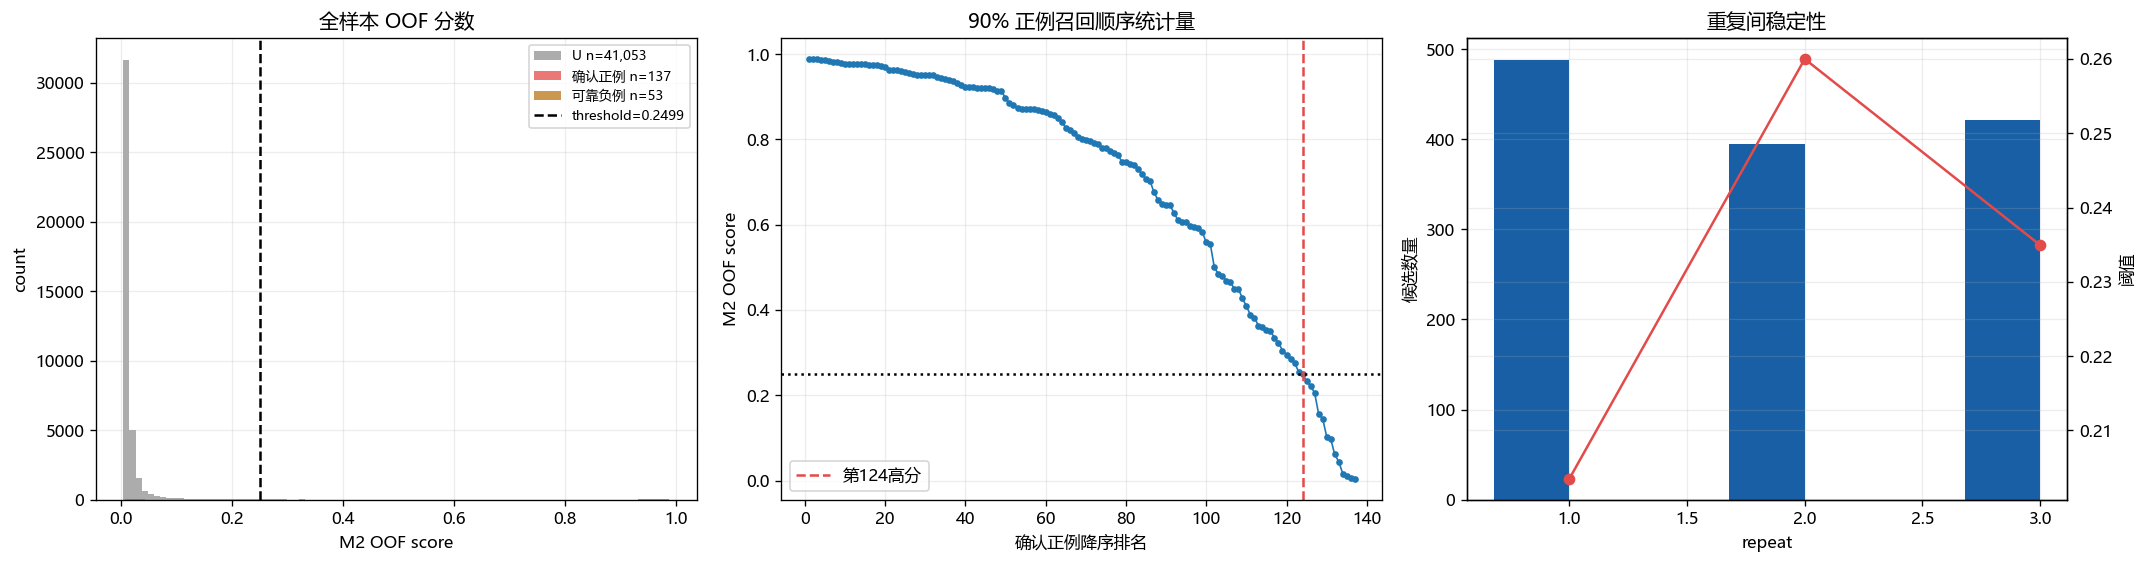

In [8]:
score = np.asarray(m2_result["score_mean"])
threshold = float(m2_result["threshold"])
pos_score = score[status == 1]
neg_score = score[status == -1]
u_score = score[status == 0]
ordered = np.sort(pos_score)[::-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
axes[0].hist(u_score, bins=90, color="gray", alpha=.65, label=f"U n={len(u_score):,}")
axes[0].hist(pos_score, bins=35, color="#E24B4A", alpha=.75, label="确认正例 n=137")
axes[0].hist(neg_score, bins=25, color="#BA7517", alpha=.75, label="可靠负例 n=53")
axes[0].axvline(threshold, color="black", ls="--", label=f"threshold={threshold:.4f}")
axes[0].set_xlabel("M2 OOF score")
axes[0].set_ylabel("count")
axes[0].set_title("全样本 OOF 分数")
axes[0].legend(fontsize=8)

axes[1].plot(np.arange(1, len(ordered)+1), ordered, marker=".", lw=1)
axes[1].axvline(124, color="#E24B4A", ls="--", label="第124高分")
axes[1].axhline(threshold, color="black", ls=":")
axes[1].set_xlabel("确认正例降序排名")
axes[1].set_ylabel("M2 OOF score")
axes[1].set_title("90% 正例召回顺序统计量")
axes[1].legend()

repeat_id = np.arange(1, m2_config.n_repeats + 1)
axes[2].bar(repeat_id - .16, m2_result["repeat_candidate_counts"], width=.32,
            color="#185FA5", label="候选数量")
ax2 = axes[2].twinx()
ax2.plot(repeat_id, m2_result["repeat_thresholds"], marker="o", color="#E24B4A",
         label="阈值")
axes[2].set_xlabel("repeat")
axes[2].set_ylabel("候选数量")
ax2.set_ylabel("阈值")
axes[2].set_title("重复间稳定性")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_m2_threshold_and_stability.png", dpi=170, bbox_inches="tight")
plt.show()

## 5. 使用全部标签训练最终 ensemble

该 ensemble 使用全部 137 个正例和 53 个可靠负例。它的 `final_model_score` 可用于候选内部的补充排序；候选是否入选仍由上一节的 OOF score 和 OOF 阈值决定。

In [9]:
final_score = train_full_ensemble(X_model, status, m2_config, progress=True)
print("final score range:", float(final_score.min()), float(final_score.max()))

full-label ensemble 10/100


full-label ensemble 20/100


full-label ensemble 30/100


full-label ensemble 40/100


full-label ensemble 50/100


...

full-label ensemble 70/100


full-label ensemble 80/100


full-label ensemble 90/100


full-label ensemble 100/100


final score range: 0.004163112516980618 0.9887597584724426


## 6. 导出候选表和 91 星识别标签表

In [10]:
paths = save_outputs(
    RESULTS_DIR,
    stars,
    mapping,
    status,
    m2_result,
    final_score,
    baseline_audit,
    newlabel_oof,
)
tables = build_output_tables(stars, old_positive, status, m2_result, final_score)
candidates = tables["candidates"]
known91 = tables["known91"]

print("候选数:", len(candidates))
print("91星可识别:", int(known91["label"].sum()))
print("91星漏检:", int((known91["label"] == 0).sum()))
display(known91.head(20))
display(candidates.head(20))

assert len(known91) == 91
assert set(known91["label"].unique()).issubset({0, 1})
assert (candidates["m2_status"] == 0).all()
assert not set(candidates["uid"].astype(str)) & set(
    stars.iloc[np.flatnonzero(status != 0)]["uid"].astype(str)
)
for name, path in paths.items():
    print(f"{name:12s}: {path}")

候选数: 393
91星可识别: 79
91星漏检: 12


,source_index,ra,dec,teff,logg,feh,lmjd,planid,spid,fiberid,...,m2_oof_score_repeat_2,m2_fold_repeat_2,m2_oof_score_repeat_3,m2_fold_repeat_3,m2_selected_at_recall90,ground_truth_label,recognition_status,positive_rank,teff_ge_5000,m2_recall90_threshold
0,5049,240.379281,6.312528,4875.66,2.296,-1.209,60768,LN160350N081347BM01,1,146,...,0.004392,1,0.004724,4,False,1,missed,91,False,0.249882
1,15744,247.521806,23.663352,5204.41,2.513,-1.549,56782,HD162506N240323V01,8,71,...,0.006700,4,0.007011,3,False,1,missed,90,True,0.249882
2,15372,188.567600,38.625637,5292.25,2.572,-1.494,56775,VB190N40V1,2,206,...,0.014487,3,0.008472,3,False,1,missed,89,True,0.249882
3,34574,16.280446,3.360074,4521.47,1.037,-2.139,59578,KII005739N014708V02,12,119,...,0.014550,4,0.022527,0,False,1,missed,88,False,0.249882
4,22229,124.936640,16.395891,5017.81,2.234,-1.045,57377,GAC124N15B2,9,160,...,0.090559,3,0.039678,0,False,1,missed,87,True,0.249882
5,33211,42.303563,55.572639,4922.13,2.106,-1.784,59135,HD030004N551117V02,14,51,...,0.168811,4,0.057153,1,False,1,missed,86,False,0.249882
6,11962,58.123758,28.702921,4698.96,1.410,-1.011,56619,GAC058N31B1,1,19,...,0.116155,4,0.074919,0,False,1,missed,85,False,0.249882
7,29994,172.105892,4.820258,5093.20,2.074,-1.114,58133,KII113634N060623B02,2,154,...,0.151132,3,0.168063,4,False,1,missed,84,True,0.249882
8,36258,330.496420,15.720241,4941.23,2.694,-0.779,59875,EG220255N140221V02,11,97,...,0.127437,2,0.210695,3,False,1,missed,83,False,0.249882
9,23560,212.106418,47.185979,5120.96,2.760,-1.115,57444,HD141351N461930V01,15,64,...,0.209303,3,0.234941,4,False,1,missed,82,True,0.249882


,candidate_rank,source_index,ra,dec,teff,logg,feh,lmjd,planid,spid,...,m2_selection_frequency,final_model_score,m2_oof_score_repeat_1,m2_fold_repeat_1,m2_oof_score_repeat_2,m2_fold_repeat_2,m2_oof_score_repeat_3,m2_fold_repeat_3,m2_selected_at_recall90,m2_recall90_threshold
0,1,13378,191.659997,7.423810,4904.80,1.935,-1.957,56671,HD124702N090350V01,1,...,1.0,0.977505,0.989204,1,0.987661,1,0.987166,4,True,0.249882
1,2,6171,225.560047,-5.115541,5230.59,2.954,-1.350,60793,LN145852S045921BM01,8,...,1.0,0.962686,0.979135,1,0.987038,4,0.977644,2,True,0.249882
2,3,15707,248.593692,23.235639,4956.85,2.472,-0.984,56782,HD162506N240323B01,6,...,1.0,0.960995,0.979536,2,0.979419,1,0.977040,1,True,0.249882
3,4,6308,170.934371,41.185576,4428.72,0.932,-1.744,60795,LN111354N395839VB01,12,...,1.0,0.965659,0.981115,2,0.975792,0,0.976998,1,True,0.249882
4,5,39848,265.818037,15.524510,4504.52,1.026,-1.868,60405,LN175147N150023VB01,14,...,1.0,0.978105,0.978113,3,0.979286,4,0.975857,3,True,0.249882
5,6,29746,189.535254,18.511835,4760.75,1.573,-1.998,58105,HD124029N161645B02,11,...,1.0,0.965882,0.969249,4,0.982769,4,0.977711,3,True,0.249882
6,7,5573,256.314353,5.577310,5107.44,2.500,-1.343,60790,LN170600N075116BM01,1,...,1.0,0.965913,0.983504,2,0.974367,1,0.965214,1,True,0.249882
7,8,24359,217.304177,42.755187,4364.52,0.757,-1.837,57475,HD143120N432256V01,5,...,1.0,0.972783,0.968090,0,0.972974,4,0.973996,4,True,0.249882
8,9,7500,267.024952,28.366495,4599.48,1.304,-1.656,60825,LN175745N291452VB01,10,...,1.0,0.968707,0.974927,3,0.972194,1,0.960202,1,True,0.249882
9,10,10448,210.134970,49.551926,4513.10,1.133,-1.817,56427,HD140817N492729B01,3,...,1.0,0.970562,0.960843,0,0.972461,0,0.972308,1,True,0.249882


candidates  : D:\资料\2026大创\Lamost\m2_crossfit\results\m2_candidates_recall90.csv
known91     : D:\资料\2026大创\Lamost\m2_crossfit\results\known91_recognition_labels.csv
labelled_oof: D:\资料\2026大创\Lamost\m2_crossfit\results\m2_labelled_oof_scores.csv
history     : D:\资料\2026大创\Lamost\m2_crossfit\results\m2_training_history.csv
arrays      : D:\资料\2026大创\Lamost\m2_crossfit\results\m2_all_scores.npz
summary     : D:\资料\2026大创\Lamost\m2_crossfit\results\m2_summary.json


### 6.1 91 颗旧证认星：识别与漏检特征

导出表中的 `ground_truth_label` 恒为 1；新 `label` 表示模型在 M2 90% 正例召回阈值下能否识别。这里重点检查温度、金属丰度、重力和 SNR 是否与漏检有关。

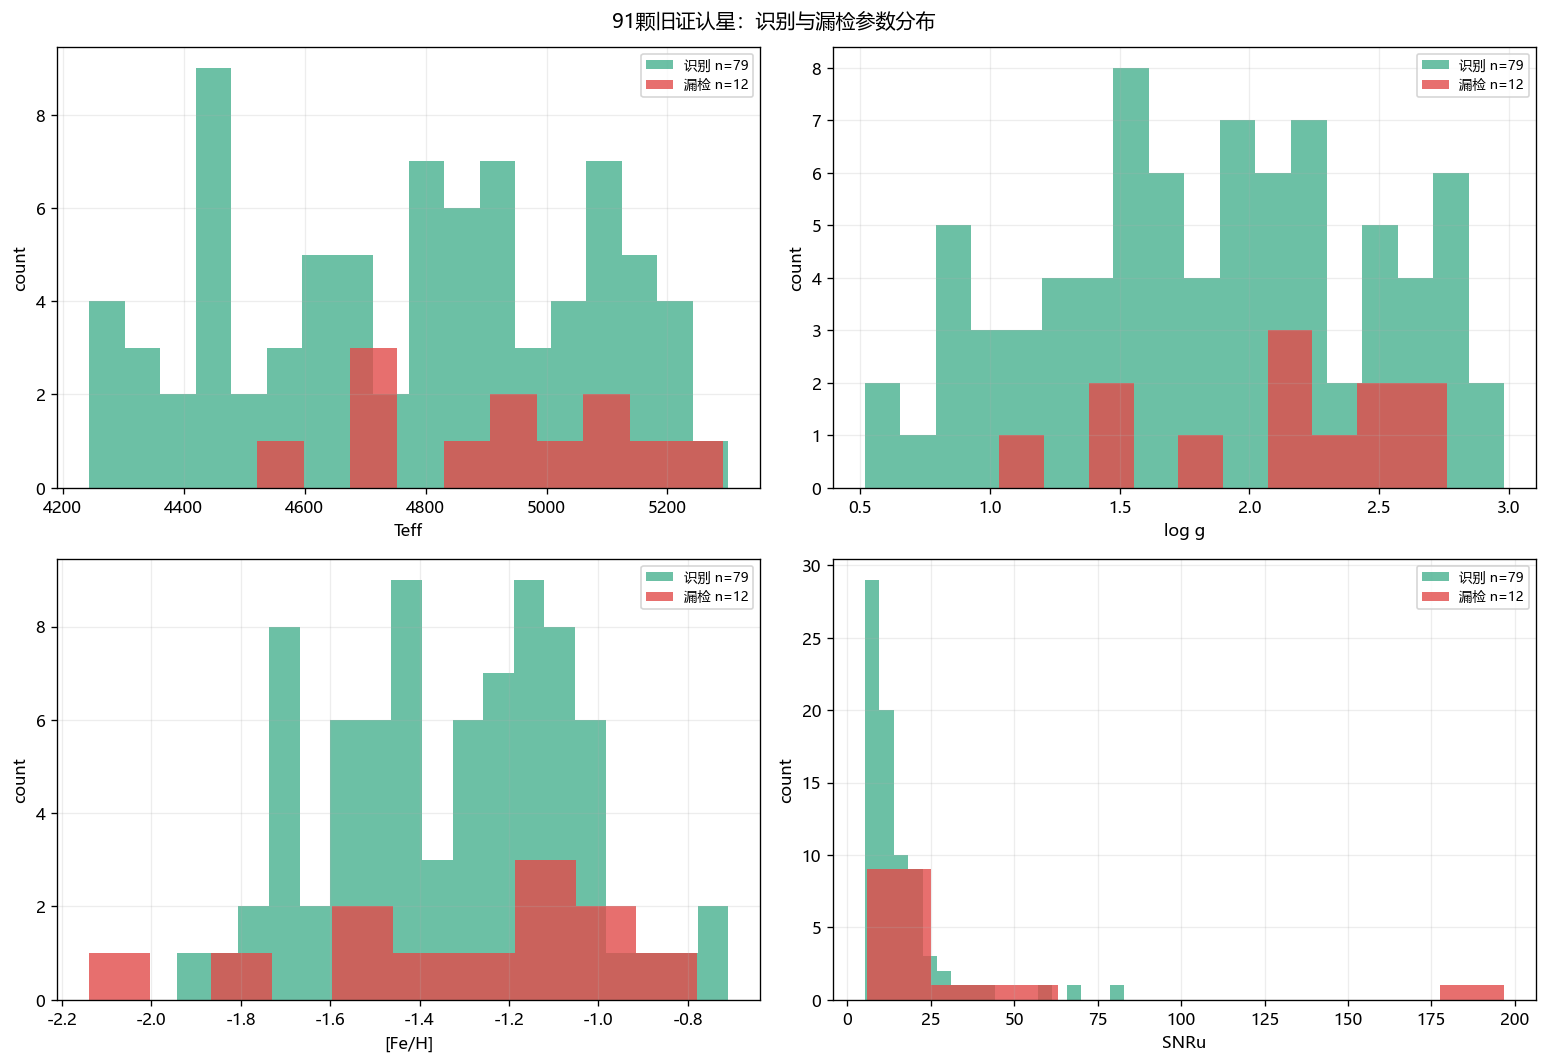

,uid,ra,dec,teff,logg,feh,snru,m2_oof_score,m2_repeat_std,m2_selection_frequency,positive_rank,recognition_status
0,G14496634487950,240.379281,6.312528,4875.66,2.296,-1.209,15.91,0.004570,0.000167,0.000000,91,missed
1,G14502488465511,247.521806,23.663352,5204.41,2.513,-1.549,45.71,0.007000,0.000295,0.000000,90,missed
2,G14991477032180,188.567600,38.625637,5292.25,2.572,-1.494,10.66,0.011340,0.003017,0.000000,89,missed
3,G17075963539662,16.280446,3.360074,4521.47,1.037,-2.139,17.41,0.016595,0.005219,0.000000,88,missed
4,G16328857862712,124.936640,16.395891,5017.81,2.234,-1.045,7.02,0.061680,0.026128,0.000000,87,missed
5,G16854443172544,42.303563,55.572639,4922.13,2.106,-1.784,6.84,0.098071,0.061513,0.000000,86,missed
6,G17524832648575,58.123758,28.702921,4698.96,1.410,-1.011,6.31,0.103325,0.024639,0.000000,85,missed
7,G15450913353811,172.105892,4.820258,5093.20,2.074,-1.114,29.40,0.145311,0.026153,0.000000,84,missed
8,G13382890379345,330.496420,15.720241,4941.23,2.694,-0.779,13.52,0.156032,0.047356,0.000000,83,missed
9,L15165848963165,212.106418,47.185979,5120.96,2.760,-1.115,196.79,0.206076,0.030607,0.333333,82,missed


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, column, label_text in zip(
    axes.ravel(),
    ["teff", "logg", "feh", "snru"],
    ["Teff", "log g", "[Fe/H]", "SNRu"],
):
    recognized = known91.loc[known91["label"] == 1, column].dropna()
    missed = known91.loc[known91["label"] == 0, column].dropna()
    ax.hist(recognized, bins=18, alpha=.65, color="#1D9E75", label=f"识别 n={len(recognized)}")
    ax.hist(missed, bins=10, alpha=.8, color="#E24B4A", label=f"漏检 n={len(missed)}")
    ax.set_xlabel(label_text)
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
fig.suptitle("91颗旧证认星：识别与漏检参数分布")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_known91_recognition_parameters.png", dpi=170, bbox_inches="tight")
plt.show()

missed91 = known91.loc[known91["label"] == 0, [
    "uid", "ra", "dec", "teff", "logg", "feh", "snru",
    "m2_oof_score", "m2_repeat_std", "m2_selection_frequency",
    "positive_rank", "recognition_status"
]]
display(missed91)

### 6.2 候选参数分布

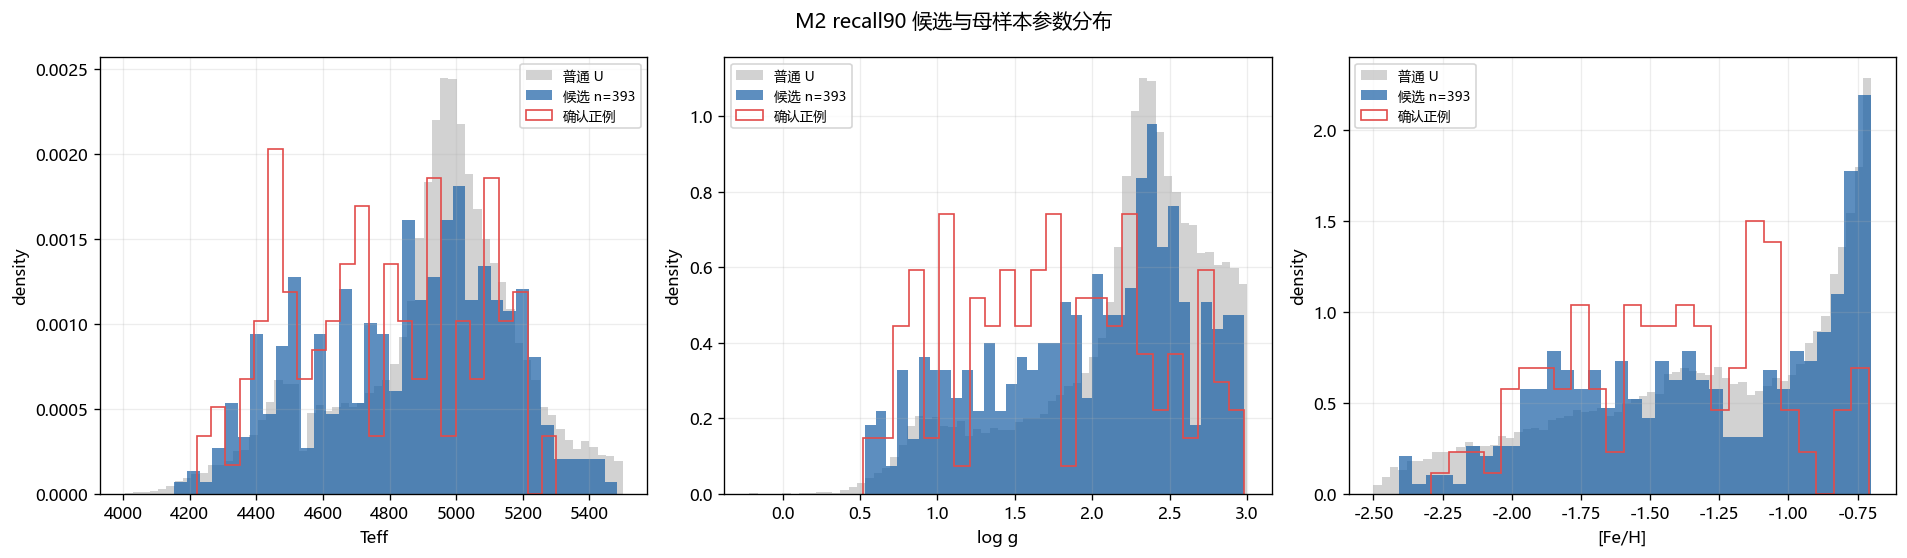

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.7))
u_mask = status == 0
for ax, column, text_label in zip(
    axes,
    ["teff", "logg", "feh"],
    ["Teff", "log g", "[Fe/H]"],
):
    ax.hist(stars.loc[u_mask, column], bins=60, density=True, alpha=.35,
            color="gray", label="普通 U")
    ax.hist(candidates[column], bins=35, density=True, alpha=.70,
            color="#185FA5", label=f"候选 n={len(candidates):,}")
    ax.hist(stars.iloc[np.flatnonzero(status == 1)][column], bins=25,
            density=True, histtype="step", lw=2, color="#E24B4A", label="确认正例")
    ax.set_xlabel(text_label)
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
fig.suptitle("M2 recall90 候选与母样本参数分布")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_candidate_parameters.png", dpi=170, bbox_inches="tight")
plt.show()

### 6.3 最高分候选光谱

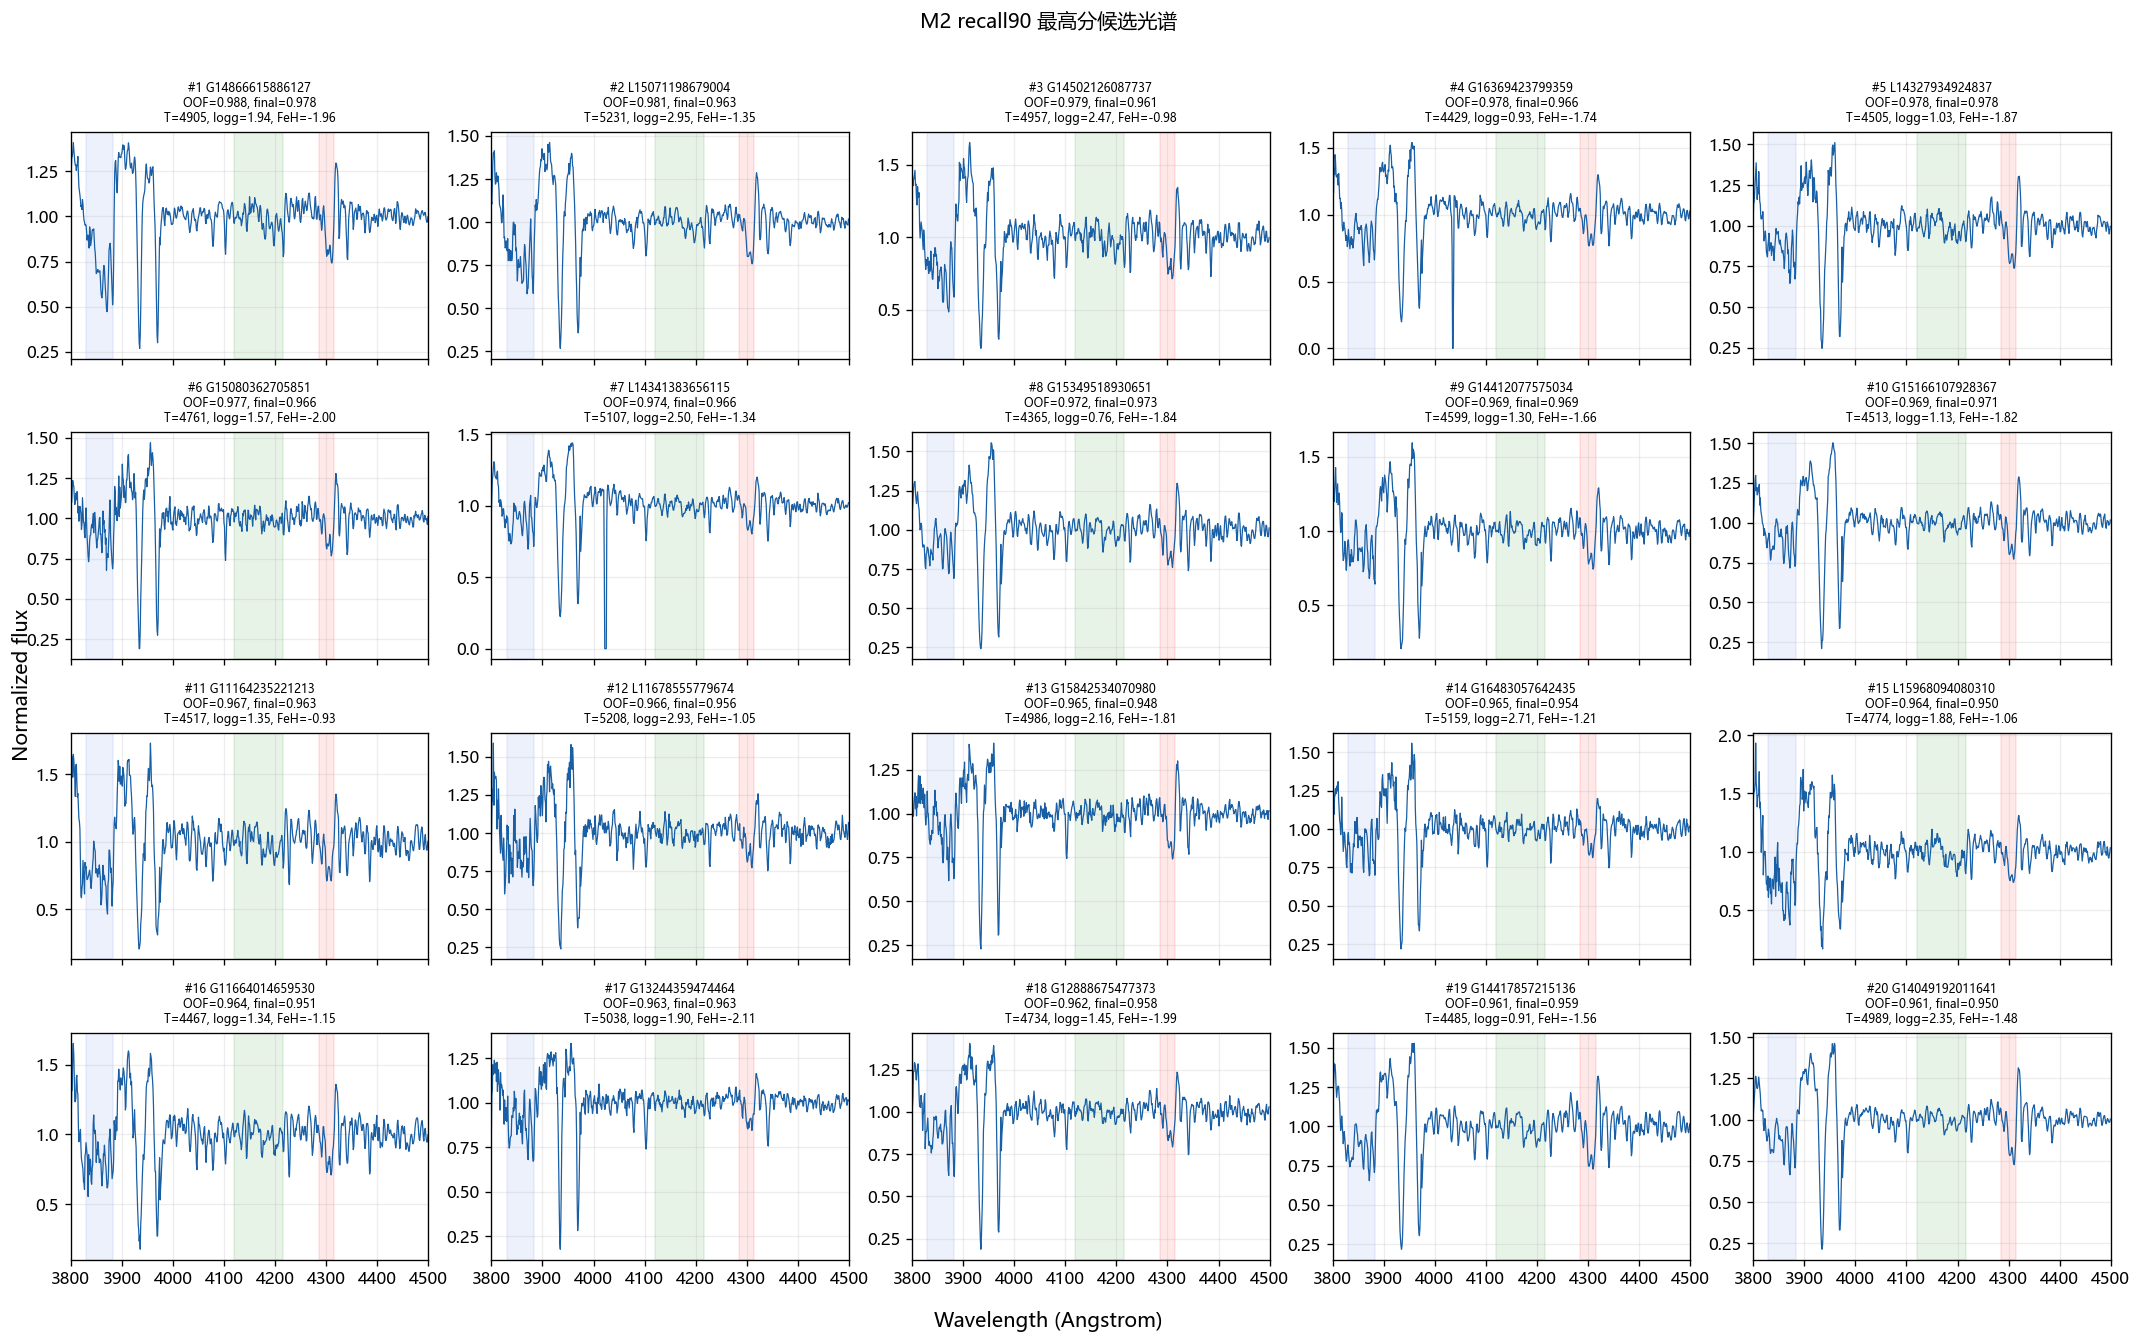

In [13]:
top = candidates.sort_values("m2_oof_score", ascending=False).head(20).reset_index(drop=True)
fig, axes = plt.subplots(4, 5, figsize=(18, 11), sharex=True)
for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
    idx = int(row["source_index"])
    ax.plot(wave, np.asarray(data["X_clean"])[idx], color="#185FA5", lw=.75)
    for left, right, colour, name in [
        (3830, 3883, "royalblue", "CN3839"),
        (4120, 4216, "green", "CN4142"),
        (4285, 4315, "red", "CH4300"),
    ]:
        ax.axvspan(left, right, color=colour, alpha=.09)
    ax.set_title(
        f"#{int(row['candidate_rank'])} {row['uid']}\n"
        f"OOF={row['m2_oof_score']:.3f}, final={row['final_model_score']:.3f}\n"
        f"T={row['teff']:.0f}, logg={row['logg']:.2f}, FeH={row['feh']:.2f}",
        fontsize=7,
    )
    ax.set_xlim(3800, 4500)
fig.supxlabel("Wavelength (Angstrom)")
fig.supylabel("Normalized flux")
fig.suptitle("M2 recall90 最高分候选光谱", y=1.01)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_top20_candidate_spectra.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. 结果摘要与使用限制

1. `m2_oof_score` 是候选入选的权威分数；`final_model_score` 只用于候选内部补充排序。
2. 90% 指已确认正例的 OOF 召回，不是模型后验概率或候选真实性置信度。
3. 91 星表中的 `label=0` 表示模型在本阈值下漏检，不改变其真实的证认星身份。
4. 99 个新增标签来自追随观测，M2 的 OOF 指标描述该标签群体，不能直接外推为整个 DR13 的总体精度。
5. 下一批二次高分结果应作为新的独立外部测试集，避免继续用同一批 99 个标签调参与评估。

In [14]:
summary = json.loads((RESULTS_DIR / "m2_summary.json").read_text(encoding="utf-8"))
display(pd.json_normalize(summary, sep="."))
print("结果目录:", RESULTS_DIR.resolve())
print("图像目录:", FIGURE_DIR.resolve())

,n_total,n_old_positive,n_new_positive,n_reliable_negative,n_unlabeled,score_interpretation,config.u_to_p_ratio,config.max_depth,config.min_child_weight,config.reg_lambda,...,full_survey_m2_oof.labelled_pr_auc,full_survey_m2_oof.threshold,full_survey_m2_oof.required_positive,full_survey_m2_oof.achieved_positive_recall,full_survey_m2_oof.candidate_count,full_survey_m2_oof.known91_recognized,full_survey_m2_oof.known91_missed,full_survey_m2_oof.repeat_thresholds,full_survey_m2_oof.repeat_candidate_counts,full_survey_m2_oof.elapsed_seconds
0,41243,91,46,53,41053,M2 scores are ranking scores under constructed...,10,3,1,1.0,...,0.970624,0.249882,124,0.905109,393,79,12,"[0.20349439404904843, 0.2599981703609228, 0.23...","[488, 395, 421]",2373.613718


结果目录: D:\资料\2026大创\Lamost\m2_crossfit\results
图像目录: D:\资料\2026大创\Lamost\m2_crossfit\results\figures
